# 01. EDA — NASA C-MAPSS FD001

**목적:** 모델링 전에 데이터를 이해하고, 이후 전처리 단계에서 사용할 **유효 센서 후보**를 선별한다.

**이 노트북의 범위 (중요)**
- 한다: 분포 확인, 기초 통계, 센서 분산 분석, 무변화 센서 식별, 대표 엔진 시계열, RUL-센서 상관관계
- 하지 않는다: 정규화 / Piecewise Linear RUL / 피처 엔지니어링 / 모델링 → 모두 다음 단계로 분리

> 왜 EDA만 따로 떼는가: 전처리·모델링을 섞으면 "데이터를 이해해서 내린 결정"과 "성능을 위해 가한 변형"의 경계가 흐려진다. 여기서는 **데이터가 말해주는 사실**만 확인한다.


## 1. 셋업 및 데이터 로딩

`src/data_loader.py`의 로딩 함수를 재사용한다. 타깃(RUL)이 포함된 `data/processed/train_with_rul.csv`를 함께 불러온다.


In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 노트북이 notebooks/ 안에서 실행되어도 src를 임포트할 수 있게 경로 추가
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT / "src"))

from data_loader import load_fd001_data, get_fd001_columns, validate_loaded_data

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4)

SENSORS = [f"sensor_{i}" for i in range(1, 22)]
SETTINGS = [f"op_setting_{i}" for i in range(1, 4)]


In [2]:
# 원본 로딩 + 구조 검증 (Step 01에서 고정한 로직 재사용)
train, test, rul = load_fd001_data(ROOT / "data" / "raw")
print("로딩 검증:", validate_loaded_data(train, test, rul)["passed"])

# RUL이 포함된 처리 데이터 로딩
df = pd.read_csv(ROOT / "data" / "processed" / "train_with_rul.csv")
print("train_with_rul shape:", df.shape)
df.head()


로딩 검증: True
train_with_rul shape: (20631, 27)


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


## 2. 엔진별 수명(cycle 길이) 분포

각 엔진이 고장까지 몇 사이클을 살았는지를 본다. 이 분포는 "엔진마다 수명이 얼마나 다른가"를 알려주며, 이후 RUL 클리핑 값(예: 125)을 정할 때 근거가 된다.


min    128
25%    177
50%    199
75%    229
max    362
Name: cycle, dtype: int64
평균 수명: 206.3 cycle


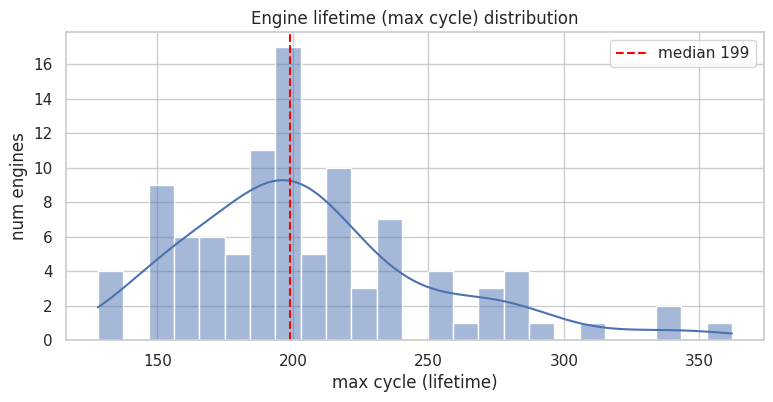

In [3]:
life = df.groupby("engine_id")["cycle"].max()
print(life.describe()[["min", "25%", "50%", "75%", "max"]].astype(int))
print("평균 수명: %.1f cycle" % life.mean())

plt.figure()
sns.histplot(life, bins=25, kde=True)
plt.axvline(life.median(), color="red", linestyle="--", label=f"median {int(life.median())}")
plt.title("Engine lifetime (max cycle) distribution")
plt.xlabel("max cycle (lifetime)"); plt.ylabel("num engines"); plt.legend()
plt.show()


## 3. RUL 분포

타깃 변수 RUL의 분포. 선형 정의이므로 0부터 최대 수명까지 고르게 퍼지지만, 값이 큰 구간(초기 사이클)은 실제 열화가 거의 없다 — 이것이 다음 단계에서 **Piecewise Linear RUL 클리핑**이 필요한 이유다. (여기서는 사실만 관찰하고 변형은 하지 않는다.)


RUL min/mean/max: 0 / 107.8 / 361


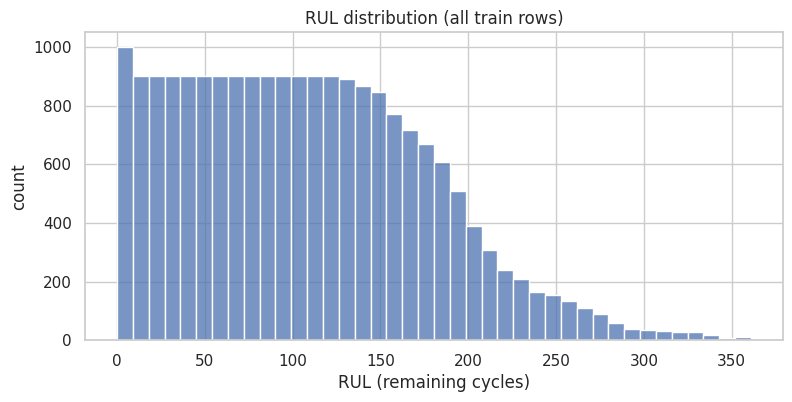

In [4]:
print("RUL min/mean/max: %d / %.1f / %d" % (df.RUL.min(), df.RUL.mean(), df.RUL.max()))

plt.figure()
sns.histplot(df.RUL, bins=40)
plt.title("RUL distribution (all train rows)")
plt.xlabel("RUL (remaining cycles)"); plt.ylabel("count")
plt.show()


## 4. 센서별 기초 통계

21개 센서의 스케일과 범위를 확인한다. 단위·범위가 제각각이라 다음 단계에서 정규화가 필요함을 미리 확인할 수 있다.


In [5]:
desc = df[SENSORS].describe().T[["mean", "std", "min", "max"]]
desc


,mean,std,min,max
sensor_1,518.670000,0.000000e+00,518.6700,518.6700
sensor_2,642.680934,5.000533e-01,641.2100,644.5300
sensor_3,1590.523119,6.131150e+00,1571.0400,1616.9100
sensor_4,1408.933782,9.000605e+00,1382.2500,1441.4900
sensor_5,14.620000,5.329200e-15,14.6200,14.6200
sensor_6,21.609803,1.388985e-03,21.6000,21.6100
sensor_7,553.367711,8.850923e-01,549.8500,556.0600
sensor_8,2388.096652,7.098548e-02,2387.9000,2388.5600
sensor_9,9065.242941,2.208288e+01,9021.7300,9244.5900
sensor_10,1.300000,0.000000e+00,1.3000,1.3000


## 5. 센서 분산 분석 → 무변화 센서 식별 (핵심)

표준편차가 0이거나 0에 가까운 센서는 엔진 상태와 무관하게 **항상 같은 값**이라 RUL 예측에 정보를 주지 못한다. 이런 센서를 제거 후보로 식별한다. (실제 제거는 다음 전처리 단계에서 수행)


완전 상수 센서 (std=0): ['sensor_1', 'sensor_10', 'sensor_19', 'sensor_18']
준상수 센서 (0<std<0.01): ['sensor_16', 'sensor_5', 'sensor_6']
→ 제거 후보 총 7 개


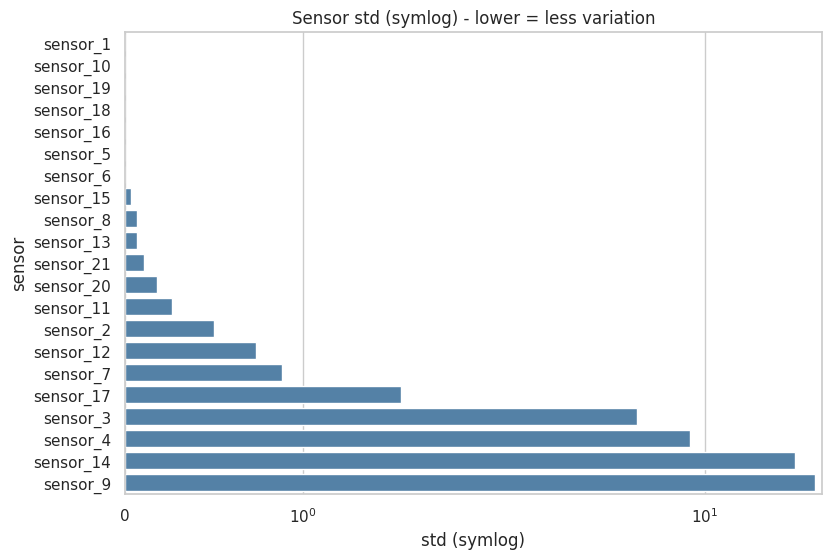

In [6]:
std = df[SENSORS].std().sort_values()

const_sensors = std[std == 0].index.tolist()              # 완전 상수
near_const   = std[(std > 0) & (std < 0.01)].index.tolist()  # 준상수

print("완전 상수 센서 (std=0):", const_sensors)
print("준상수 센서 (0<std<0.01):", near_const)
print("→ 제거 후보 총", len(const_sensors) + len(near_const), "개")

plt.figure(figsize=(9, 6))
sns.barplot(x=std.values, y=std.index, color="steelblue")
plt.xscale("symlog")
plt.title("Sensor std (symlog) - lower = less variation")
plt.xlabel("std (symlog)"); plt.ylabel("sensor")
plt.show()


## 6. 대표 엔진의 센서 시계열 변화 (수명 구간별)

수명이 짧은/중간/긴 엔진을 각각 골라, 정보가 있는 대표 센서가 고장에 가까워질수록 어떻게 변하는지 본다. 수명 구간을 나누면 특정 엔진의 우연한 패턴인지, 여러 구간에서 일관되게 나타나는 열화 신호인지 구분할 수 있다.


대표 엔진: {'short': 'engine 39 (life 128)', 'mid': 'engine 26 (life 199)', 'long': 'engine 69 (life 362)'}


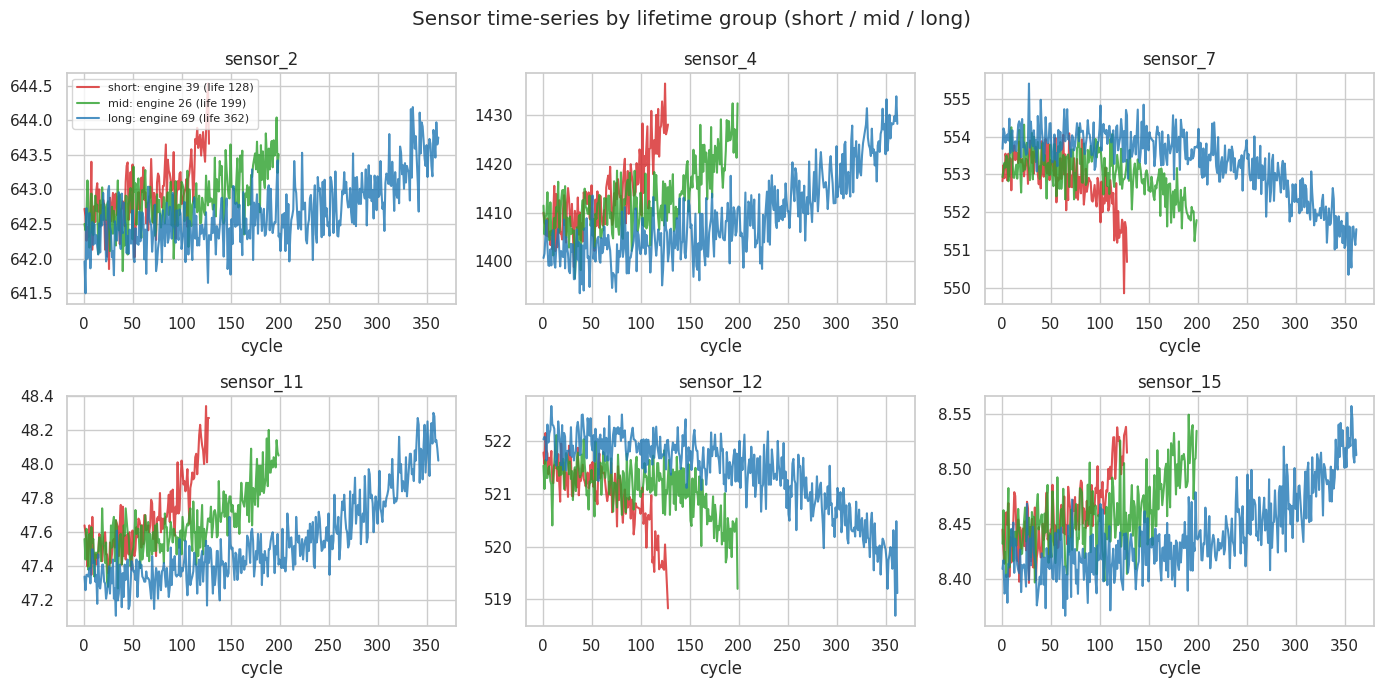

In [7]:
# 정보가 있는 대표 센서 (열화에 따라 단조 추세를 보이는 것으로 알려진 센서들)
example_sensors = ["sensor_2", "sensor_4", "sensor_7", "sensor_11", "sensor_12", "sensor_15"]

# 수명 구간별 대표 엔진: 짧음/중간/긺 (각 분위수에 가장 가까운 엔진)
life_sorted = life.sort_values()
short_engine = life_sorted.index[0]                       # 최단 수명
mid_engine   = (life - life.median()).abs().idxmin()      # 중앙값에 가장 가까움
long_engine  = life_sorted.index[-1]                      # 최장 수명
reps = [(short_engine, "tab:red", "short"),
        (mid_engine, "tab:green", "mid"),
        (long_engine, "tab:blue", "long")]
print("대표 엔진:", {f"{lab}": f"engine {eid} (life {int(life[eid])})" for eid, _, lab in reps})

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=False)
for ax, s in zip(axes.ravel(), example_sensors):
    for eid, color, lab in reps:
        sub = df[df.engine_id == eid]
        ax.plot(sub.cycle, sub[s], color=color, alpha=0.8,
                label=f"{lab}: engine {eid} (life {int(life[eid])})")
    ax.set_title(s); ax.set_xlabel("cycle")
axes[0, 0].legend(fontsize=8)
plt.suptitle("Sensor time-series by lifetime group (short / mid / long)")
plt.tight_layout()
plt.show()


## 7. RUL과 센서값의 상관관계

각 센서가 RUL과 얼마나 선형 관계를 갖는지 본다. 상관이 높은 센서는 이후 모델의 핵심 피처 후보가 된다. (상수 센서는 상관 계산에서 제외)


=== |RUL 상관계수| 상위 10개 ===
sensor_11   -0.696
sensor_4    -0.679
sensor_12    0.672
sensor_7     0.657
sensor_15   -0.643
sensor_21    0.636
sensor_20    0.629
sensor_2    -0.606
sensor_17   -0.606
sensor_3    -0.585
Name: RUL, dtype: float64


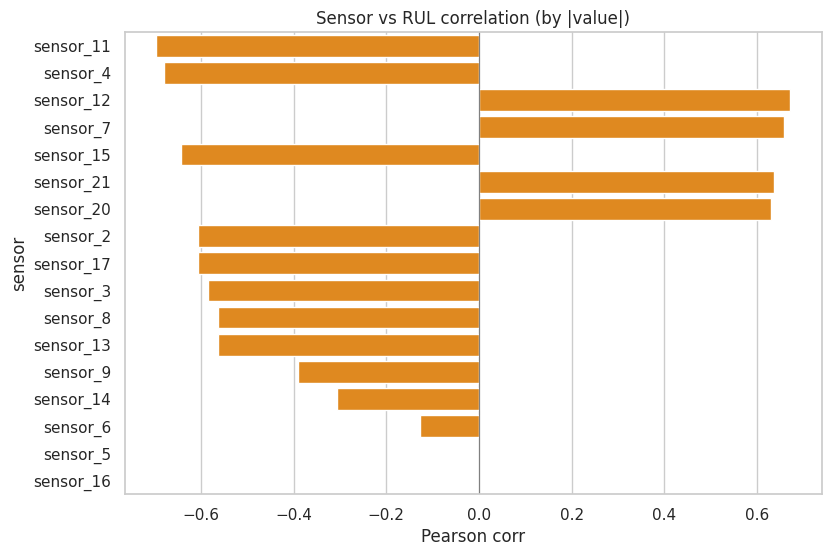

In [8]:
valid_sensors = [s for s in SENSORS if s not in const_sensors]
corr = df[valid_sensors + ["RUL"]].corr()["RUL"].drop("RUL").sort_values(key=lambda x: x.abs(), ascending=False)

print("=== |RUL 상관계수| 상위 10개 ===")
print(corr.head(10).round(3))

plt.figure(figsize=(9, 6))
sns.barplot(x=corr.values, y=corr.index, color="darkorange")
plt.title("Sensor vs RUL correlation (by |value|)")
plt.xlabel("Pearson corr"); plt.ylabel("sensor")
plt.axvline(0, color="gray", linewidth=0.8)
plt.show()


## 8. EDA 요약 및 다음 단계

- 엔진 100대, 수명 128~362 사이클(평균 약 206)
- RUL은 0~361 선형 분포 → 초기 구간 과대 RUL 문제 존재(다음 단계 클리핑 근거)
- 무변화 센서(제거 후보): `sensor_1, 5, 6, 10, 16, 18, 19`
- RUL 상관 상위 센서: `sensor_11, 4, 12, 7, 15, 21, 20, 2`

상세 정리는 `docs/02_eda_summary.md` 참고.

**다음 단계(전처리):** 무변화 센서 제거 → 정규화 → Piecewise Linear RUL 클리핑 → 피처 구성.
이 노트북에서는 변형을 가하지 않았다.
